In [ ]:
!pip install sentence-transformers seaborn matplotlib

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
sentences = [
    # Cricket (4)
    "The batsman scored a century in the final match",
    "The bowler delivered a perfect yorker",
    "The team won the match by six wickets",
    "The captain set an aggressive field placement",

    # Cooking (3)
    "The chef prepared a delicious pasta with fresh ingredients",
    "Baking a cake requires precise measurements",
    "The recipe includes spices and herbs for flavor",

    # Cybersecurity (3)
    "Strong passwords help protect against cyber attacks",
    "Encryption ensures data security during transmission",
    "Firewalls prevent unauthorized access to networks"
]

In [ ]:
model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(sentences)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
similarity_matrix = cosine_similarity(embeddings)

print("Shape of similarity matrix:", similarity_matrix.shape)

Shape of similarity matrix: (10, 10)


Text(0.5, 1.0, '10x10 Cosine Similarity Matrix')

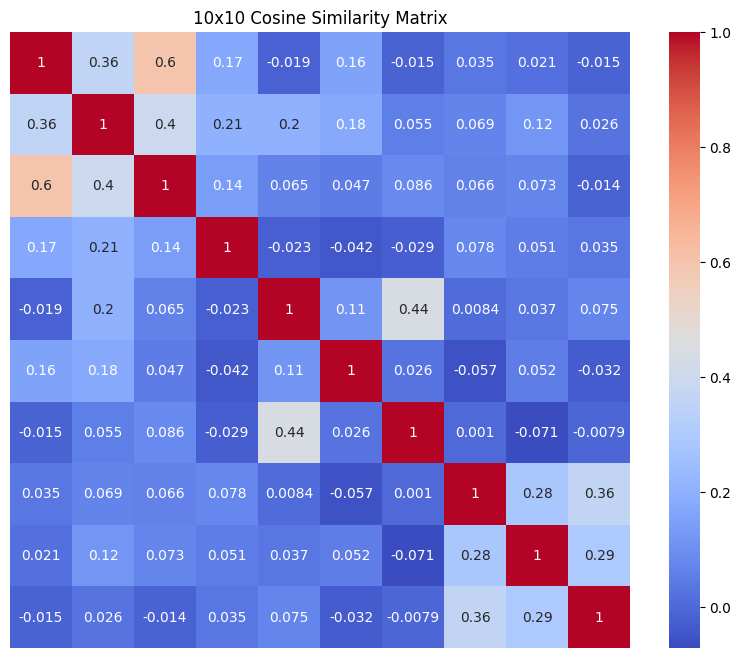

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(similarity_matrix, annot=True, cmap='coolwarm', xticklabels=False, yticklabels=False)
plt.title("10x10 Cosine Similarity Matrix")

In [ ]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]

In [ ]:
top_indices = similarities.argsort()[-2:][::-1]

print("Query:", query)
print("\nTop 2 similar sentences:\n")

for idx in top_indices:
    print(f"Sentence: {sentences[idx]}")
    print(f"Similarity Score: {similarities[idx]:.4f}")
    print()

Query: The bowler took three wickets in one over

Top 2 similar sentences:

Sentence: The team won the match by six wickets
Similarity Score: 0.7324

Sentence: The batsman scored a century in the final match
Similarity Score: 0.5707



In [ ]:
print("Sentences grouped by topics: Cricket, Cooking, Cybersecurity")

Sentences grouped by topics: Cricket, Cooking, Cybersecurity
